# PROJET D’ÉCONOMÉTRIE APPLIQUÉE

In [73]:
# imprtation du jeux de données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel("../data/donnees_immobilieres.xlsx") 

In [74]:
df = df.drop(columns=["ID"])
columns_var = df.columns
df

,Surface_m2,Chambres,Annee_construction,Distance_centre_km,Etage,Ascenseur,Annee_vente,Qualite_ecole,Revenu_median_quartier,Distance_universite,Prix_milliers_euros
0,139.87,3,1982,21.33,2,1,2023,1.1,47.5,11.9,1961.68
1,114.47,4,1991,2.90,5,1,2022,4.7,44.2,11.9,2303.67
2,145.91,2,2005,3.00,3,1,2017,3.2,53.8,10.7,2224.12
3,180.92,4,1995,29.61,3,1,2022,6.1,68.3,11.1,2425.63
4,110.63,3,2016,11.54,0,0,2021,9.0,81.9,10.8,2323.34
...,...,...,...,...,...,...,...,...,...,...,...
145,151.27,3,1992,10.20,1,0,2019,4.6,51.3,6.7,2140.32
146,70.52,2,2019,19.19,2,0,2016,4.1,42.9,3.7,1680.16
147,67.18,1,2021,7.58,4,0,2019,5.4,71.6,8.7,1902.30
148,140.88,3,1988,2.74,3,0,2020,5.0,54.4,9.5,2252.99


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Surface_m2              150 non-null    float64
 1   Chambres                150 non-null    int64  
 2   Annee_construction      150 non-null    int64  
 3   Distance_centre_km      150 non-null    float64
 4   Etage                   150 non-null    int64  
 5   Ascenseur               150 non-null    int64  
 6   Annee_vente             150 non-null    int64  
 7   Qualite_ecole           150 non-null    float64
 8   Revenu_median_quartier  150 non-null    float64
 9   Distance_universite     150 non-null    float64
 10  Prix_milliers_euros     150 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 13.0 KB


In [76]:
stats_base = df.describe()
stats_base.drop('count')

,Surface_m2,Chambres,Annee_construction,Distance_centre_km,Etage,Ascenseur,Annee_vente,Qualite_ecole,Revenu_median_quartier,Distance_universite,Prix_milliers_euros
mean,116.706800,2.886667,2001.826667,16.500267,2.580000,0.460000,2019.840000,5.468667,63.668000,8.064000,2107.904800
std,37.693819,1.077760,11.704841,9.017430,1.761901,0.500067,2.288225,1.868249,9.295458,3.746502,229.921013
min,15.210000,1.000000,1980.000000,0.830000,0.000000,0.000000,2015.000000,1.000000,42.900000,1.000000,1500.770000
25%,93.240000,2.000000,1991.000000,9.105000,1.000000,0.000000,2018.000000,4.125000,57.500000,5.300000,1934.285000
50%,117.845000,3.000000,2002.500000,16.865000,2.500000,0.000000,2020.000000,5.600000,63.450000,8.300000,2105.050000
75%,139.637500,4.000000,2012.000000,24.697500,4.000000,1.000000,2022.000000,7.000000,70.475000,10.875000,2272.780000
max,218.530000,5.000000,2022.000000,29.990000,5.000000,1.000000,2023.000000,10.000000,83.900000,17.100000,2743.040000


In [ ]:
skew_prix = df["Prix_milliers_euros"].skew()
kurt_prix = df["Prix_milliers_euros"].kurt()

print(f'Asymétrie (skewness) du prix :{skew_prix:.3f}')
print(f'Aplatissement (kurtosis) du prix :{kurt_prix:.3f}')



Asymétrie (skewness) du prix :0.156
Aplatissement (kurtosis) du prix :-0.469


(None,)

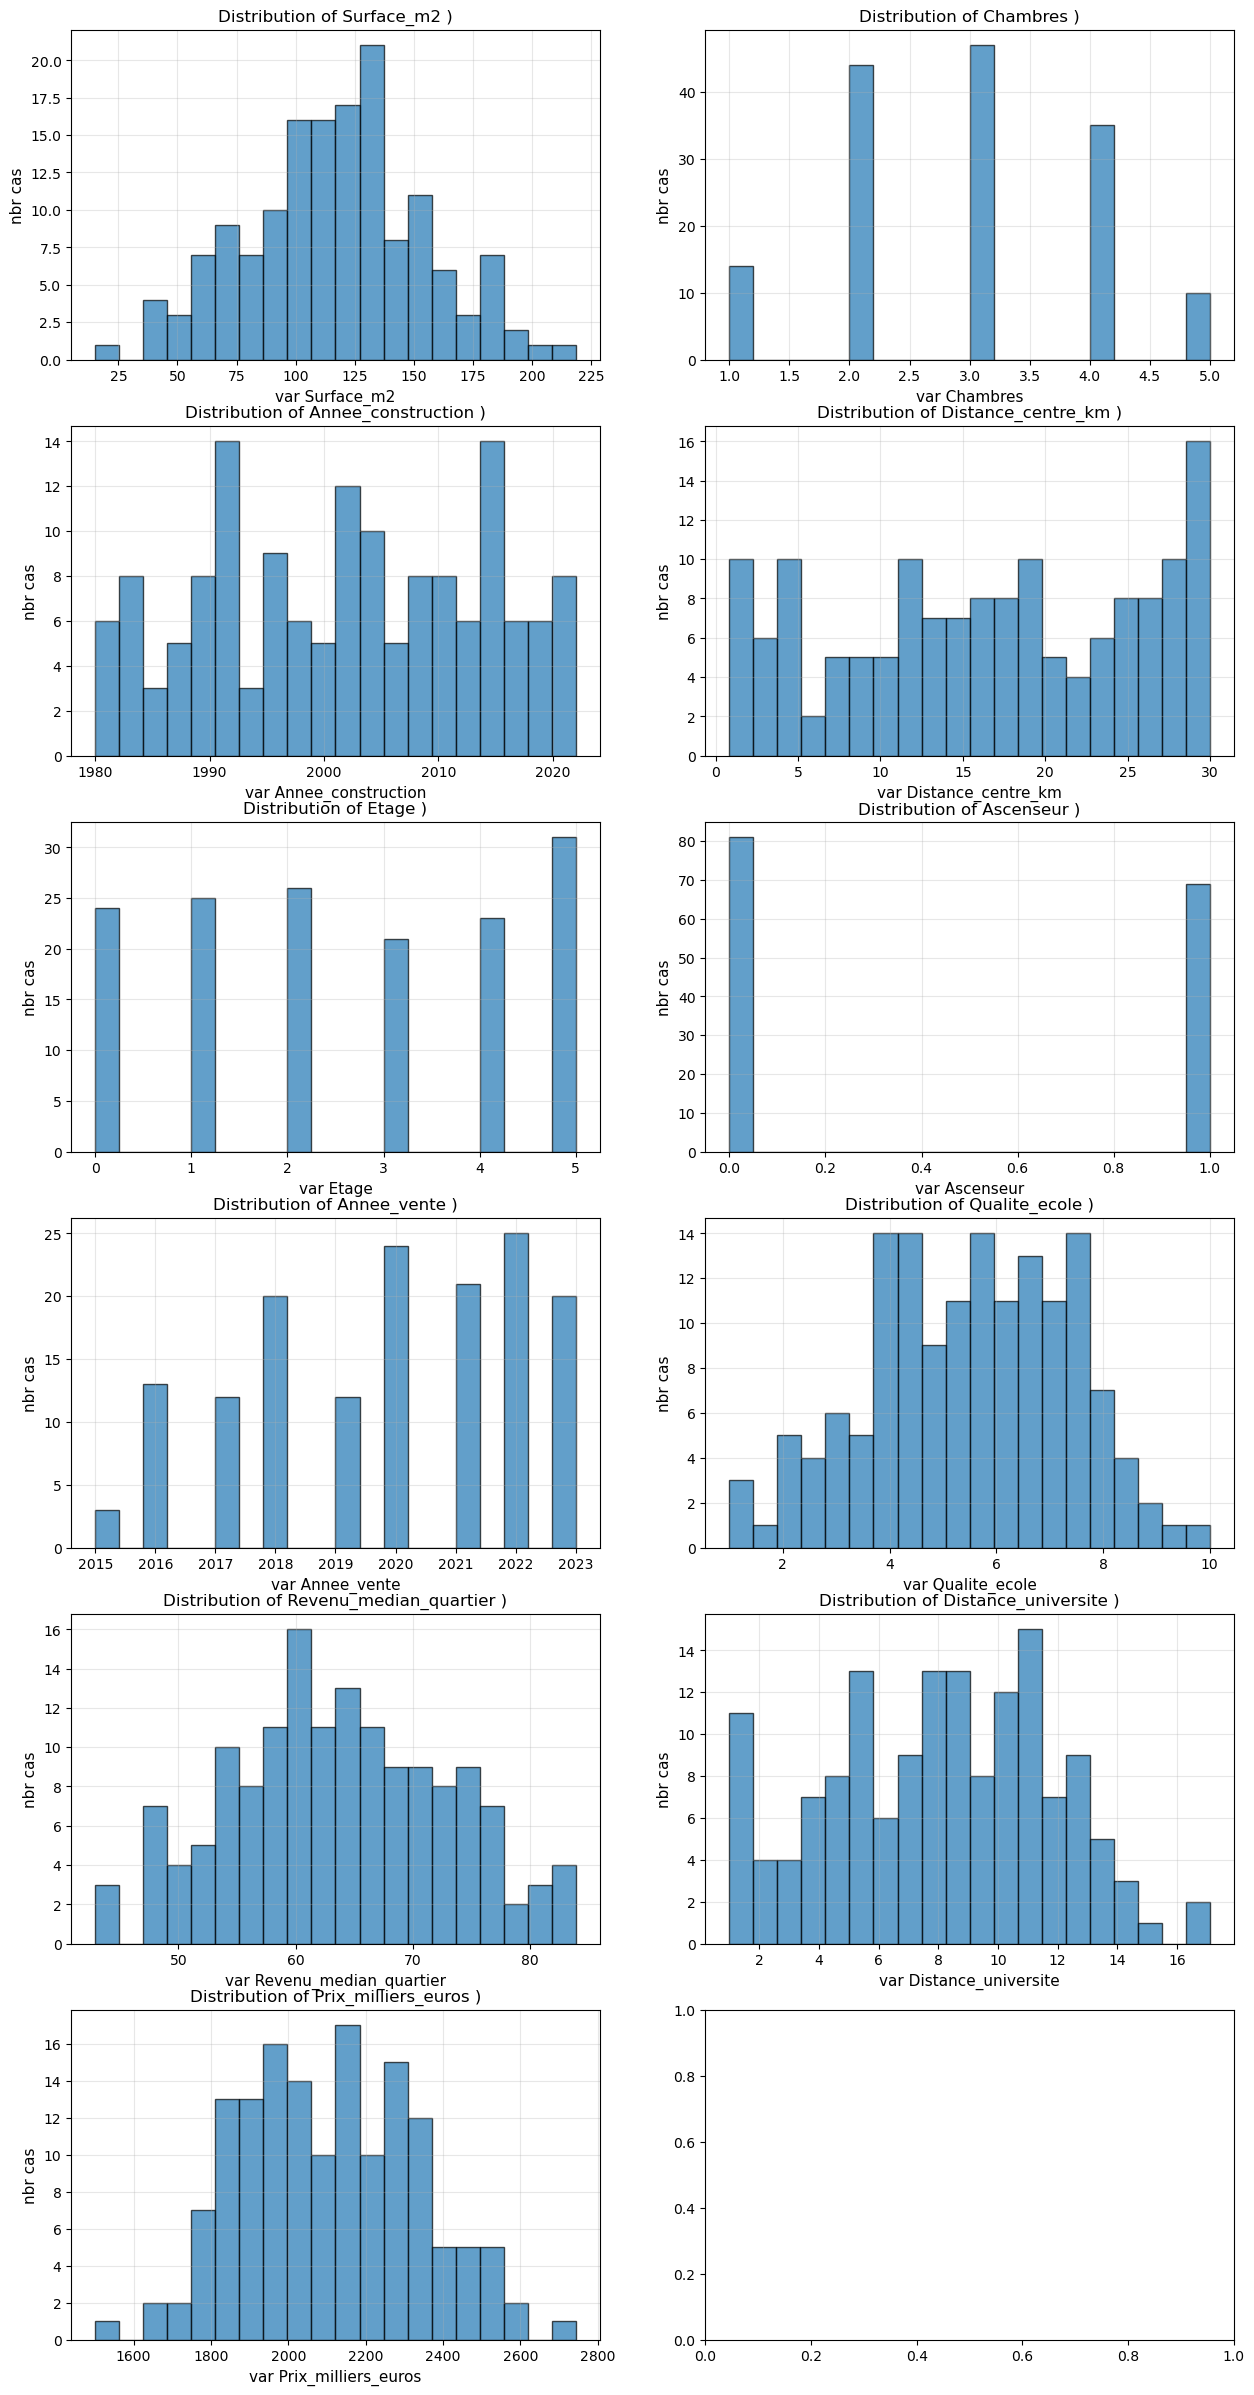

In [78]:
fig_line = 6
fig_col = 2
fig, axes = plt.subplots(fig_line, fig_col, figsize=(15, 30))
k=0

for i in range(fig_line):
    for j in range(fig_col):
        if k < 11 :
            var = columns_var[k]
            axes[i, j].hist(df[var], bins=20, edgecolor='black', alpha=0.7)
            axes[i, j].set_xlabel(f'var {var}', fontsize=11)
            axes[i, j].set_ylabel('nbr cas', fontsize=11)
            axes[i, j].set_title(f'Distribution of {var} )', fontsize=12)
            axes[i, j].grid(True, alpha=0.3)
            k += 1


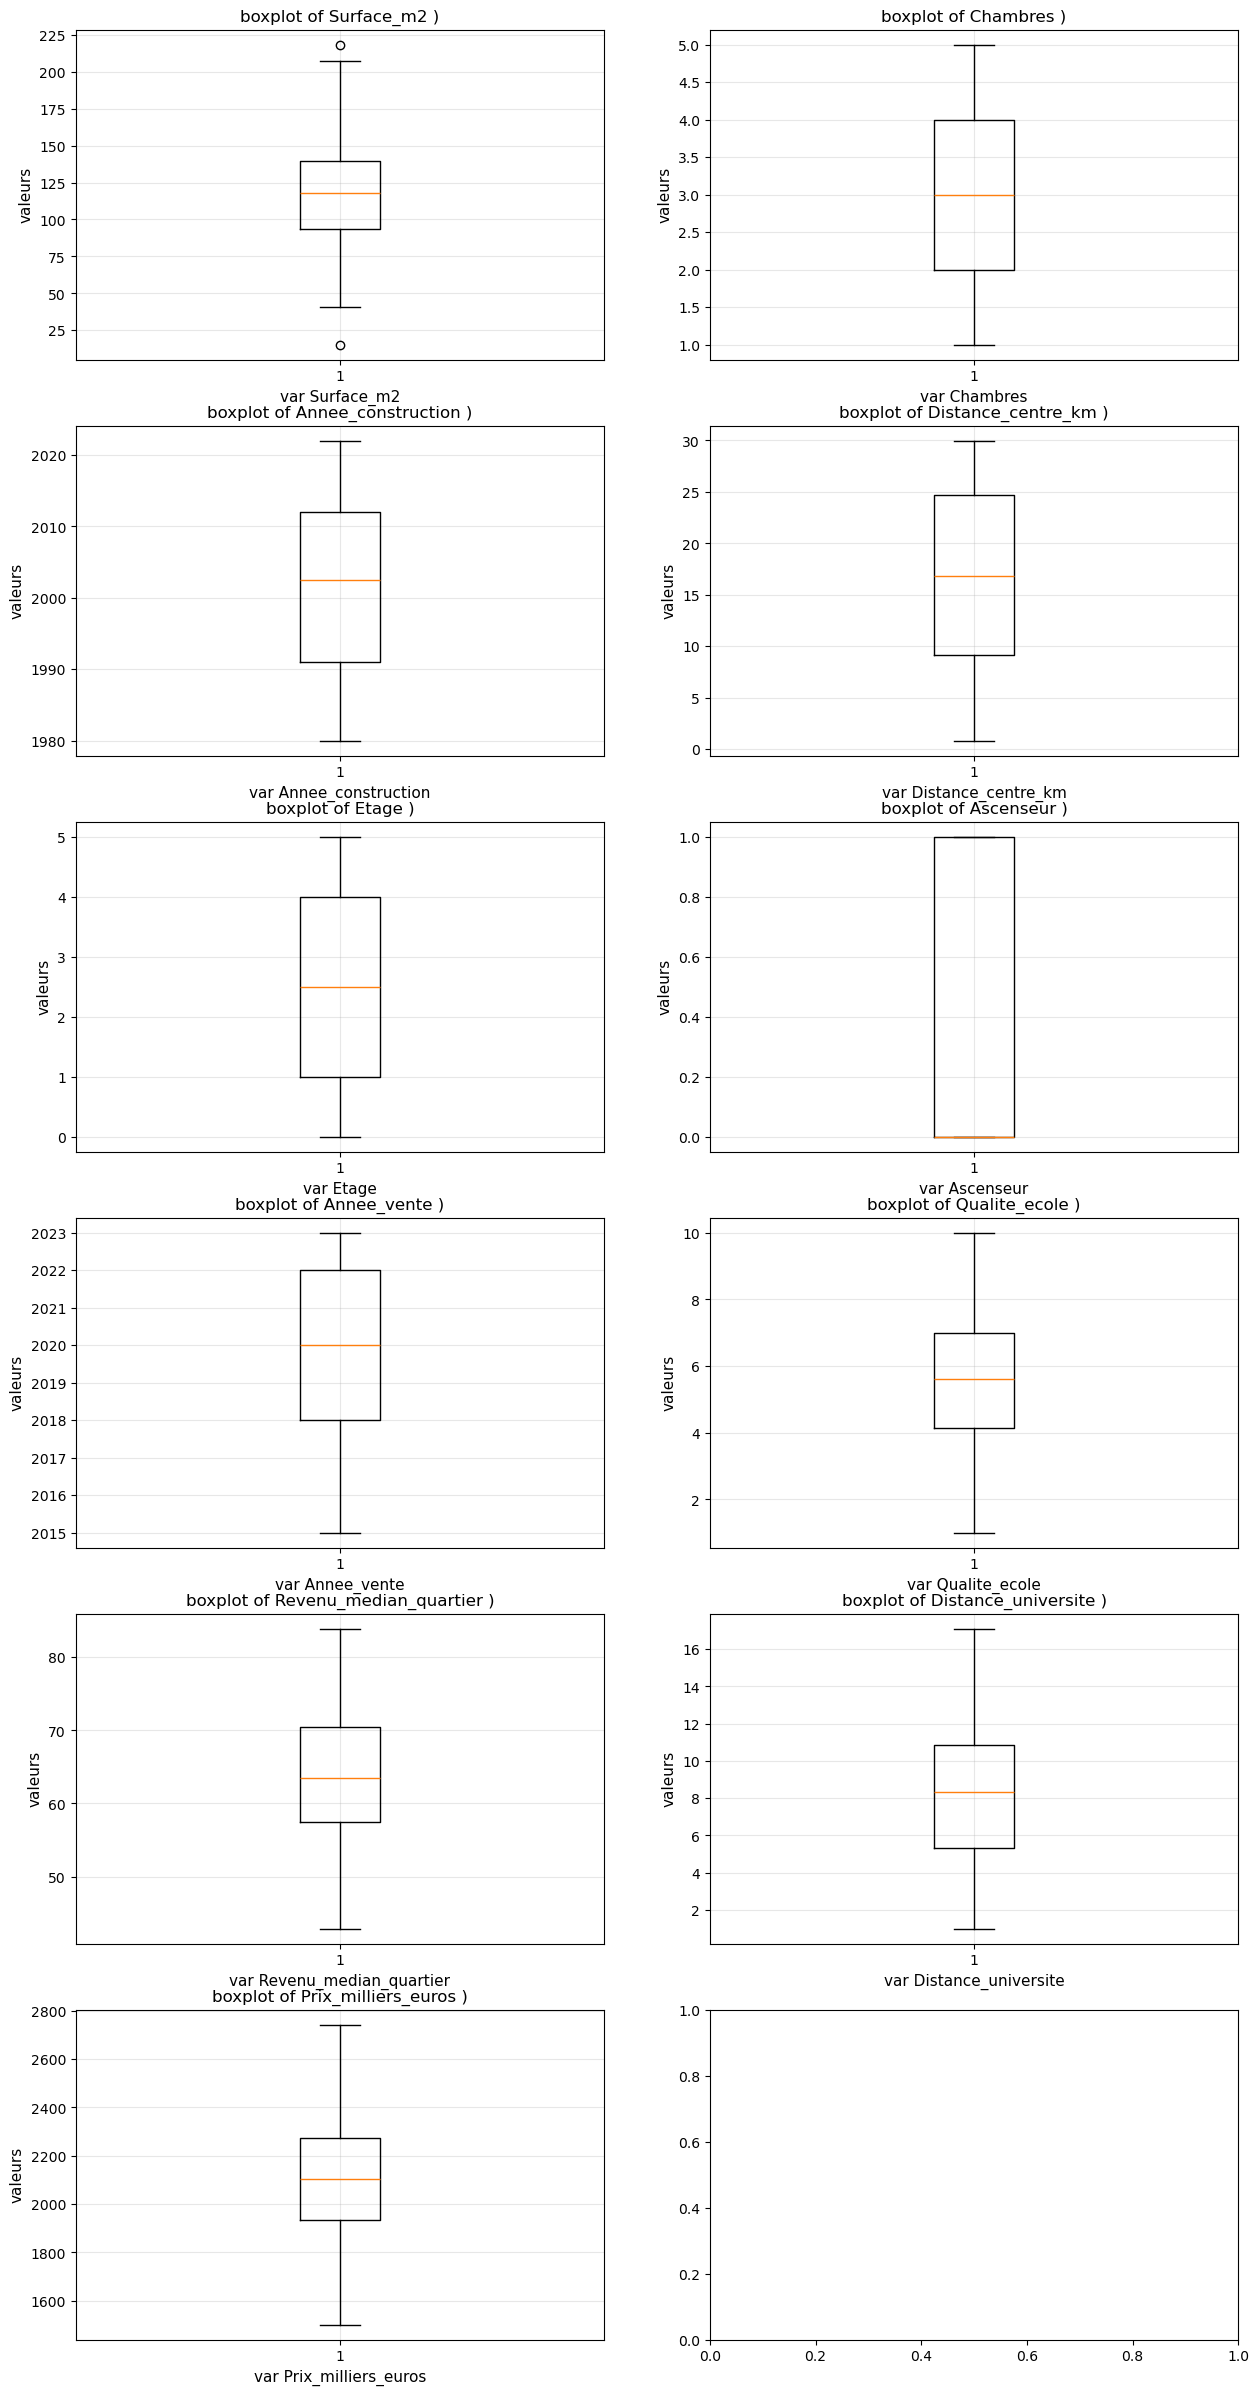

In [79]:
fig, axes = plt.subplots(fig_line, fig_col, figsize=(15, 30))
k=0

for i in range(fig_line):
    for j in range(fig_col):
        if k < 11 :
            var = columns_var[k]
            axes[i, j].boxplot(df[var])
            axes[i, j].set_xlabel(f'var {var}', fontsize=11)
            axes[i, j].set_ylabel('valeurs', fontsize=11)
            axes[i, j].set_title(f'boxplot of {var} )', fontsize=12)
            axes[i, j].grid(True, alpha=0.3)
            k += 1

### Corrélations

In [81]:
# corrélations
corr_pearson = df.corr(method="pearson")
print(corr_pearson)

                        Surface_m2  Chambres  Annee_construction  \
Surface_m2                1.000000  0.590959           -0.034333   
Chambres                  0.590959  1.000000            0.039398   
Annee_construction       -0.034333  0.039398            1.000000   
Distance_centre_km       -0.074765 -0.102319           -0.088117   
Etage                     0.061126  0.048986           -0.044559   
Ascenseur                -0.062416 -0.014694           -0.100949   
Annee_vente               0.060417  0.036140           -0.055920   
Qualite_ecole             0.043832 -0.012775           -0.009887   
Revenu_median_quartier    0.013908  0.011761            0.030304   
Distance_universite      -0.088362 -0.089609           -0.006250   
Prix_milliers_euros       0.826731  0.614825            0.068358   

                        Distance_centre_km     Etage  Ascenseur  Annee_vente  \
Surface_m2                       -0.074765  0.061126  -0.062416     0.060417   
Chambres               